### <h1 align="center" >Fig. 2c, 2g: Spindle and chromosome dynamics plots</h1>

Dynamics plot to visualize the average spindle length elongation and the average chromosome segregation as a function time for each developmental cell stage of different embryonic conditions. Each developmental cell stage in the plot is denoted with a unique symbol and color code for easy visualization.

**`Input file`:** *.CSV* file containing the data of the pole-to-pole distance over time for each experiment.

The table below shows the table structure of each .csv file. The headers of each table should show the time series measurement value from each observation which starts with prefix, **Exp**, and the standard devation of each experiment.


|Exp00 | Exp01 | Exp02 | Exp00_std | Exp01_std | Exp02_std |
| :-----: | :-----: | :-----: |:---------:|:---------:|:---------:|
| `num` | `num` | `num` |   `num`   |   `num`   |   `num`   |
| `...` | `...` | `...` |   `...`   |   `...`   |   `...`   |



**`OUTPUT FILES`**

A **.PNG** file showing a combined dynamics plots of different cell stages.


In [69]:
# library
import os
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from typing import Tuple, List
import warnings

In [70]:
# input folder
folder = r'E:\data\Analysis Data\01_python_analysis\input'
fileTable = os.listdir(folder)

# # output folder
save_files = r'E:\data\Analysis Data\01_python_analysis\output_new'

In [71]:
# create a dictionary of colors
# colors = {'2-cell': '#006600', 
#          '4-cell': '#330066',
#          '8-cell': '#FFAA33',
#          '16-cell': '#3333FF',
#          '24-30-cell': '#00FFFF',
#          '32-64-cell': '#b84873'}

# markers used for the plots for each developmental stage
markers = {'2-cell': 's',
         '4-cell': 'D',
         '8-cell': '^',
         '16-cell': 'o',
         '24-30-cell': 'H',
         '32-64-cell': 'p'}

### Load the input file folder and add the files to a placeholder, *file_List*

In [72]:
def fileLoader(folder_input: str, file_input: List[str], csvfilename: str) -> List[pd.DataFrame]:
    file_list = []
    for file in file_input:
        filepath = os.path.join(folder_input, file)
        filename = os.path.basename(filepath)
        if filename == csvfilename:
            try:
                df = pd.read_csv(filepath, index_col=None, encoding='utf-8')
            except UnicodeDecodeError:
                df = pd.read_csv(filepath, index_col=None, encoding='cp1252')
            file_list.append(df)
    return file_list

### Create new df of the data and the standard deviation

In [73]:
def fileList(csvfilename: str, folder: str, file_input: List[str]) -> Tuple[pd.DataFrame, pd.DataFrame]:
    if not os.path.exists(folder):
        raise FileNotFoundError("The specified folder does not exist")
    mean_df_table = fileLoader(folder, file_input, csvfilename)
    
    if not mean_df_table:
        raise ValueError("No valid CSV file found")
        
    mean_df_table = mean_df_table[0]
    time_column = mean_df_table.loc[:, mean_df_table.columns.str.startswith('time')]
    data_table = mean_df_table.loc[:, mean_df_table.columns.str.endswith('cell')]
    std_table = mean_df_table.loc[:, mean_df_table.columns.str.contains('std')]
    df1 = pd.concat([time_column, data_table], axis=1).dropna()
    df2 = pd.concat([time_column, std_table], axis=1).dropna()
    return df1, df2

In [74]:
# '''Combined Pole-to-pole distance plot for all the embryonic stages'''
# def groupPoleDistancePlot(csvfilename, folder, file_input, folder_save, plotfilename, plot_color):
#
#     # mean and std tables
#     mean_table = fileList(csvfilename, folder, file_input)[0]
#     std_table = fileList(csvfilename, folder, file_input)[1]
#
#     # suppress warning message
#     warnings.filterwarnings("ignore", category=FutureWarning)
#
#     sns.set_style(style=None) # seaborn plot style initialization
#
#     plt.figure(figsize=(7,7))
#     for cellname, marker in markers.items():
#
#     # for cellname in colors.keys():
#         # ax = sns.lineplot(data=mean_table, x='time', y=cellname, color=colors[cellname], linewidth=3)
#         # ax = sns.scatterplot(data=mean_table, x='time', y=cellname, color=colors[cellname], s=80)
#         # ax.errorbar(x=mean_table['time'], y=mean_table[cellname], yerr=std_table[cellname+'_std'], capsize=2, elinewidth=1, fmt='none', color=colors[cellname])
#
#         ax = sns.lineplot(data=mean_table, x='time', y=cellname, color=plot_color, linewidth=4, alpha=1)
#         ax = sns.scatterplot(data=mean_table, x='time', y=cellname, marker=marker, s=140, color='gray')
#         ax.errorbar(x=mean_table['time'], y=mean_table[cellname], yerr=std_table[cellname+'_std'], capsize=2, elinewidth=1, fmt='none', color=plot_color)
#
#     if ax:
#         # Set major locator for x-axis and y-axis to only use integer values
#         ax.xaxis.set_major_locator(MaxNLocator(integer=True))
#         ax.yaxis.set_major_locator(MaxNLocator(integer=True))
#         ax.set(xlim=(-105.5-0.5, 200), ylim=(0, 24.5+0.5))
#         plt.yticks(np.arange(0, 25, 3))
#         plt.xticks(np.arange(-90-10, 210+10, 30))
#
#         # add a vertical line at time 0 sec to indicate anaphase onset
#         ax.vlines(x=0, ymin=0, ymax=27, linestyle='solid', color='orange', alpha=0.6, linewidth=4)
#         ax.tick_params(axis='x', labelsize=10)
#         ax.tick_params(axis='y', labelsize=10)
#         ax.tick_params(axis='both', which='major', labelsize=15)
#         ax.tick_params(axis='x', direction='in')
#         ax.tick_params(axis='y', direction='in')
#         ax.set_xlabel('Time [s]', fontsize=20)
#         ax.set_ylabel('Pole-to-pole distance [µm]', fontsize=25)
#         ax.figure.savefig(os.path.join(folder_save, plotfilename), dpi=300, bbox_inches='tight')
#     return None

In [75]:
'''Combined Pole-to-pole distance plot for all the embryonic stages'''
def groupPoleDistancePlotColor(csvfilename, folder, file_input, folder_save, plotfilename):

    stages = ['2-cell', '4-cell', '8-cell', '16-cell', '24-30-cell', '32-64-cell']
    palettes = ['#006600', '#330066', '#FFAA33', '#3333FF', '#00FFFF', '#b84873']
    symbols = ['s', 'D', '^', 'o', 'H', 'p']

    # mean and std tables
    mean_table = fileList(csvfilename, folder, file_input)[0]
    std_table = fileList(csvfilename, folder, file_input)[1]

    # suppress warning message
    warnings.filterwarnings("ignore", category=FutureWarning)
    sns.set_style(style=None) # seaborn plot style initialization
    plt.figure(figsize=(8,8))

    for stage, color, symbol in zip(stages, palettes, symbols):
        ax = sns.scatterplot(data=mean_table, x='time', y=stage, color=color, marker=symbol, s=150, alpha=1)
        ax = sns.lineplot(data=mean_table, x='time', y=stage, color=color, linewidth=4, alpha=1)
        ax.errorbar(x=mean_table['time'], y=mean_table[stage], yerr=std_table[stage+'_std'], capsize=2, elinewidth=1, fmt='none', color=color)

    if ax:
        # Set major locator for x-axis and y-axis to only use integer values
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        ax.set(xlim=(-105.5-0.5, 200), ylim=(0, 24.5+0.5))
        plt.yticks(np.arange(0, 25, 3))
        plt.xticks(np.arange(-90-10, 210+10, 30))

        # add a vertical line at time 0 sec to indicate anaphase onset
        ax.vlines(x=0, ymin=0, ymax=27, linestyle='solid', color='gray', alpha=0.6, linewidth=4)
        ax.tick_params(axis='both', which='major', labelsize=15, direction='in', size=12)
        ax.set_xlabel('Time [s]', fontsize=20)
        ax.set_ylabel('Pole-to-pole distance (µm)', fontsize=25)
        ax.figure.savefig(os.path.join(folder_save, plotfilename+'.png'), dpi=400, bbox_inches='tight')
        ax.figure.savefig(os.path.join(folder_save, plotfilename+'.svg'), dpi=400, bbox_inches='tight')
    return None

In [76]:
# '''Combined chromosome-to-chromosome distance plot for all the embryonic stages'''
# def groupChromosomeDistancePlot(csvfilename, folder, file_input, folder_save, plotfilename, plot_color):
#
#     # mean and std tables
#     mean_table = fileList(csvfilename, folder, file_input)[0]
#     std_table = fileList(csvfilename, folder, file_input)[1]
#
#     # suppress warning message
#     warnings.filterwarnings("ignore", category=FutureWarning)
#
#     sns.set_style(style=None) # seaborn plot style initialization
#     plt.figure(figsize=(7,7))
#     # for cellname in colors.keys():
#     #     ax = sns.lineplot(data=mean_table, x='time', y=cellname, color=colors[cellname], linewidth=3)
#     #     ax = sns.scatterplot(data=mean_table, x='time', y=cellname, color=colors[cellname], s=80)
#     #     ax.errorbar(x=mean_table['time'], y=mean_table[cellname], yerr=std_table[cellname+'_std'], capsize=2, elinewidth=1, fmt='none', color=colors[cellname])
#
#     for cellname, marker in markers.items():
#         ax = sns.lineplot(data=mean_table, x='time', y=cellname, color=plot_color, linewidth=4)
#         ax = sns.scatterplot(data=mean_table, x='time', y=cellname, marker=marker, color='gray', s=150, edgecolors='black')
#         ax.errorbar(x=mean_table['time'], y=mean_table[cellname], yerr=std_table[cellname+'_std'], capsize=2, elinewidth=1, fmt='none', color=plot_color)
#
#     if ax:
#         # Set major locator for x-axis and y-axis to only use integer values
#         ax.xaxis.set_major_locator(MaxNLocator(integer=True))
#         ax.yaxis.set_major_locator(MaxNLocator(integer=True))
#         # ax.set(xlim=(-1, 210), ylim=(0, 9))
#         ax.set(xlim=(-1, 210), ylim=(0, 24.5+0.5))
#         # plt.yticks(np.arange(0, 10, 2))
#         plt.xticks(np.arange(0, 220, 30))
#
#         # add a vertical line at time 0 sec to indicate anaphase onset
#         ax.vlines(x=0, ymin=0, ymax=30, linestyle='solid', color='orange', alpha=0.6, linewidth=4)
#         ax.tick_params(axis='x', labelsize=10)
#         ax.tick_params(axis='y', labelsize=10)
#         ax.tick_params(axis='both', which='major', labelsize=15)
#         ax.tick_params(axis='x', direction='in')
#         ax.tick_params(axis='y', direction='in')
#         ax.set_xlabel('Time [s]', fontsize=20)
#         ax.set_ylabel('Chromosome-to-chromosome \ndistance [µm]', fontsize=25)
#         ax.figure.savefig(os.path.join(folder_save, plotfilename), dpi=300, bbox_inches='tight')

In [77]:
'''Combined chromosome-to-chromosome distance plot for all the embryonic stages'''
def groupChromosomeDistancePlotColor(csvfilename, folder, file_input, folder_save, plotfilename):
    
    stages = ['2-cell', '4-cell', '8-cell', '16-cell', '24-30-cell', '32-64-cell']
    palettes = ['#006600', '#330066', '#FFAA33', '#3333FF', '#00FFFF', '#b84873']
    symbols = ['s', 'D', '^', 'o', 'H', 'p']
    
    # mean and std tables
    mean_table = fileList(csvfilename, folder, file_input)[0]
    std_table = fileList(csvfilename, folder, file_input)[1]
    
    # suppress warning message
    warnings.filterwarnings("ignore", category=FutureWarning)

    sns.set_style(style=None) # seaborn plot style initialization
    plt.figure(figsize=(8,8))

    for stage, color, symbol in zip(stages, palettes, symbols):
        ax = sns.scatterplot(data=mean_table, x='time', y=stage, color=color, marker=symbol, s=150, edgecolors='black', alpha=1)
        ax = sns.lineplot(data=mean_table, x='time', y=stage, color=color, linewidth=4, alpha=1)
        ax.errorbar(x=mean_table['time'], y=mean_table[stage], yerr=std_table[stage+'_std'], capsize=2, elinewidth=1, fmt='none', color=color)
        
    if ax:
        # Set major locator for x-axis and y-axis to only use integer values
        ax.xaxis.set_major_locator(MaxNLocator(integer=True)) 
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        # ax.set(xlim=(-1, 210), ylim=(0, 9))
        ax.set(xlim=(-6, 210), ylim=(-2, 24.5+0.5))
        # plt.yticks(np.arange(0, 10, 2))
        plt.xticks(np.arange(0, 220, 30))

        # add a vertical line at time 0 sec to indicate anaphase onset
        ax.vlines(x=0, ymin=-4, ymax=30, linestyle='solid', color='gray', alpha=0.6, linewidth=4)
        ax.tick_params(axis='both', which='major', labelsize=15, direction='in', size=12)
        ax.set_xlabel('Time [s]', fontsize=20)
        ax.set_ylabel('Chromosome-to-chromosome \ndistance (µm)', fontsize=25)
        ax.figure.savefig(os.path.join(folder_save, plotfilename+'.png'), dpi=400, bbox_inches='tight')
        ax.figure.savefig(os.path.join(folder_save, plotfilename+'.tif'), dpi=400, bbox_inches='tight')

In [78]:
# groupPoleDistancePlot('mean_P_P_cell_stage (WT).csv', folder, fileTable, save_files, 'pole-to-pole_group_plot_with_markers (WT)', '#004C99')

### Call pole-to-pole distance function

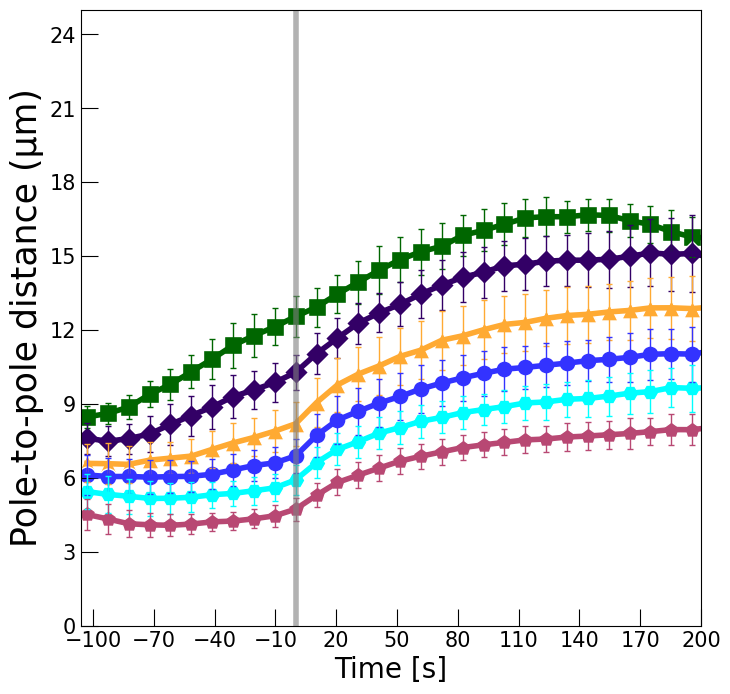

In [79]:
groupPoleDistancePlotColor('mean_P_P_cell_stage (small).csv', folder, fileTable, save_files, 'pole-to-pole_group_plot_with_markers_colors (small)') 

In [80]:
# groupChromosomeDistancePlot('mean_C_C_cell_stage (WT).csv', folder, fileTable, save_files, 'Chromosome-to-chromosome_group_plot_with_markers(WT)', '#004C99')

### Call chromosome-to-chromosome distance function

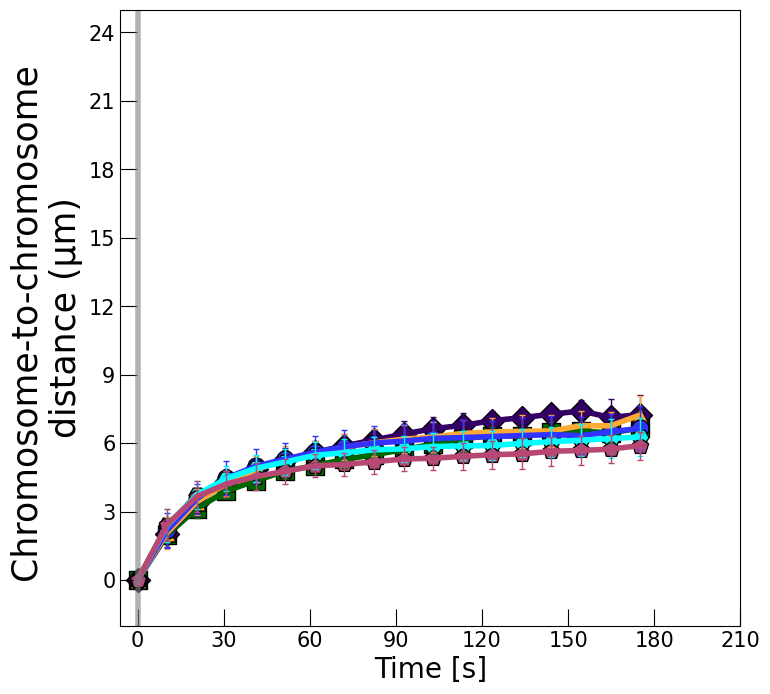

In [81]:
groupChromosomeDistancePlotColor('mean_C_C_cell_stage (small).csv', folder, fileTable, save_files, 'Chromosome-to-chromosome_group_plot_with_markers_with_colors(small)')